# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [15]:
# Capstone — Research Question

print("""
RESEARCH QUESTION
-----------------
Can a simple, interpretable scoring approach identify content pages
that should be prioritized for human review and possible refresh,
using content age and recent performance trend signals?

DECISION SUPPORTED
------------------
The analysis supports prioritization of pages for human review.
It does not claim that a refresh will cause improved performance.

The practical decision is whether a page should be:
- prioritized for refresh review,
- investigated further, or
- monitored without immediate action.
""")


RESEARCH QUESTION
-----------------
Can a simple, interpretable scoring approach identify content pages
that should be prioritized for human review and possible refresh,
using content age and recent performance trend signals?

DECISION SUPPORTED
------------------
The analysis supports prioritization of pages for human review.
It does not claim that a refresh will cause improved performance.

The practical decision is whether a page should be:
- prioritized for refresh review,
- investigated further, or
- monitored without immediate action.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [16]:
# Capstone — Data

import os
import pandas as pd

REPO = "/content/flyrank-ml-internship-starter"

if not os.path.exists(REPO):
    !git clone -q https://github.com/Sameer99-star/flyrank-ml-internship-starter.git

DATA_PATH = f"{REPO}/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)

print("DATA SOURCE")
print("-----------")
print("Dataset: content_refresh_anonymized.csv")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

print("\nDATA USED")
print("---------")
print("Content-level observations from the FlyRank internship dataset.")
print("Primary signals used for this capstone:")
print("- days_since_last_update")
print("- trend_pct")

print("\nEXCLUSIONS")
print("----------")
print("No client names, private queries, credentials, or raw private search data are used.")
print("Future-window or label-derived inputs are not used in the scoring rule.")
print("The analysis uses the available anonymized content-level dataset.")

DATA SOURCE
-----------
Dataset: content_refresh_anonymized.csv
Rows: 30000
Columns: 44

DATA USED
---------
Content-level observations from the FlyRank internship dataset.
Primary signals used for this capstone:
- days_since_last_update
- trend_pct

EXCLUSIONS
----------
No client names, private queries, credentials, or raw private search data are used.
Future-window or label-derived inputs are not used in the scoring rule.
The analysis uses the available anonymized content-level dataset.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [17]:
# Capstone — Methodology

import numpy as np

# Use the same interpretable baseline logic validated in ML-07.
model_df = df.copy()

model_df["score"] = (
    model_df["days_since_last_update"].fillna(0).clip(lower=0) / 30
    + model_df["trend_pct"].fillna(0).clip(upper=0).abs() / 10
)

model_df["action"] = np.where(
    model_df["score"] > 0,
    "REFRESH",
    "MONITOR"
)

model_df["reason_code"] = np.where(
    model_df["score"] > 0,
    "AGE_AND_DECLINE",
    "NO_STRONG_DECLINE"
)

# Rank highest-priority candidates first.
model_df = model_df.sort_values(
    ["score", "days_since_last_update"],
    ascending=[False, False]
).reset_index(drop=True)

model_df["rank"] = model_df.index + 1

print("""
METHODOLOGY
-----------
Approach:
An interpretable rule-based scoring baseline was used to prioritize
content for human review.

FEATURES
--------
- days_since_last_update: content age/freshness signal.
- trend_pct: recent directional performance signal.

SCORING
-------
score = days_since_last_update / 30
        + abs(negative trend_pct) / 10

Only negative trend_pct contributes to the decline component.

BASELINE
--------
The baseline is a simple prioritization rule rather than a causal model.
It provides a transparent reference for ranking content opportunities.

VALIDATION / LEAKAGE CONTROL
----------------------------
The scoring inputs are content age and observed recent trend.
No future-window outcome or label-derived input is used by the rule.

LIMITATION
----------
The score indicates prioritization strength, not the expected causal
impact of refreshing a page.
""")

print(f"Rows scored: {len(model_df)}")
print("\nTop 10 ranked candidates:")
display(
    model_df[
        [
            "rank",
            "content_id",
            "score",
            "action",
            "reason_code",
            "days_since_last_update",
            "trend_pct"
        ]
    ].head(10)
)


METHODOLOGY
-----------
Approach:
An interpretable rule-based scoring baseline was used to prioritize
content for human review.

FEATURES
--------
- days_since_last_update: content age/freshness signal.
- trend_pct: recent directional performance signal.

SCORING
-------
score = days_since_last_update / 30
        + abs(negative trend_pct) / 10

Only negative trend_pct contributes to the decline component.

BASELINE
--------
The baseline is a simple prioritization rule rather than a causal model.
It provides a transparent reference for ranking content opportunities.

VALIDATION / LEAKAGE CONTROL
----------------------------
The scoring inputs are content age and observed recent trend.
No future-window outcome or label-derived input is used by the rule.

LIMITATION
----------
The score indicates prioritization strength, not the expected causal
impact of refreshing a page.

Rows scored: 30000

Top 10 ranked candidates:


,rank,content_id,score,action,reason_code,days_since_last_update,trend_pct
0,1,content_f6fdf87348f6,22.433333,REFRESH,AGE_AND_DECLINE,373,-100.0
1,2,content_1b4ec72dafd4,22.400000,REFRESH,AGE_AND_DECLINE,372,-100.0
2,3,content_55a5b1c46474,21.283333,REFRESH,AGE_AND_DECLINE,373,-88.5
3,4,content_7a888d3d99c8,20.433333,REFRESH,AGE_AND_DECLINE,313,-100.0
4,5,content_94991fe6268c,20.433333,REFRESH,AGE_AND_DECLINE,313,-100.0
5,6,content_ab18b5811c02,20.166667,REFRESH,AGE_AND_DECLINE,305,-100.0
6,7,content_84d12054c0c0,20.133333,REFRESH,AGE_AND_DECLINE,304,-100.0
7,8,content_ccfb4d0227b1,20.033333,REFRESH,AGE_AND_DECLINE,301,-100.0
8,9,content_02b0d6e30129,19.993333,REFRESH,AGE_AND_DECLINE,313,-95.6
9,10,content_df1fa766cac2,19.903333,REFRESH,AGE_AND_DECLINE,304,-97.7


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [18]:
# Capstone — Results vs baseline

baseline = df.copy()

baseline["baseline_score"] = (
    baseline["days_since_last_update"].fillna(0).clip(lower=0) / 30
)

baseline["model_score"] = (
    baseline["days_since_last_update"].fillna(0).clip(lower=0) / 30
    + baseline["trend_pct"].fillna(0).clip(upper=0).abs() / 10
)

baseline["baseline_rank"] = (
    baseline["baseline_score"]
    .rank(method="first", ascending=False)
)

baseline["model_rank"] = (
    baseline["model_score"]
    .rank(method="first", ascending=False)
)

# Compare how strongly the model changes prioritization.
rank_change = (
    baseline["baseline_rank"] - baseline["model_rank"]
)

print("RESULTS VS BASELINE")
print("-------------------")
print(f"Rows compared: {len(baseline)}")
print(f"Mean absolute rank change: {rank_change.abs().mean():.2f}")
print(f"Median absolute rank change: {rank_change.abs().median():.2f}")

print("\nScore summary:")
display(
    baseline[
        ["baseline_score", "model_score"]
    ].describe().round(3)
)

print("\nTop 10 model-ranked candidates:")
display(
    baseline.sort_values(
        ["model_score", "days_since_last_update"],
        ascending=[False, False]
    )[
        [
            "content_id",
            "model_score",
            "baseline_score",
            "days_since_last_update",
            "trend_pct"
        ]
    ].head(10)
)

RESULTS VS BASELINE
-------------------
Rows compared: 30000
Mean absolute rank change: 7991.65
Median absolute rank change: 7371.00

Score summary:


,baseline_score,model_score
count,30000.000,30000.000
mean,1.537,4.815
std,1.403,3.624
min,0.033,0.033
25%,0.667,0.733
50%,0.667,4.297
75%,3.467,7.617
max,12.433,22.433



Top 10 model-ranked candidates:


,content_id,model_score,baseline_score,days_since_last_update,trend_pct
29384,content_f6fdf87348f6,22.433333,12.433333,373,-100.0
24216,content_1b4ec72dafd4,22.400000,12.400000,372,-100.0
26242,content_55a5b1c46474,21.283333,12.433333,373,-88.5
7509,content_7a888d3d99c8,20.433333,10.433333,313,-100.0
18841,content_94991fe6268c,20.433333,10.433333,313,-100.0
22860,content_ab18b5811c02,20.166667,10.166667,305,-100.0
24557,content_84d12054c0c0,20.133333,10.133333,304,-100.0
19420,content_ccfb4d0227b1,20.033333,10.033333,301,-100.0
21984,content_02b0d6e30129,19.993333,10.433333,313,-95.6
23741,content_df1fa766cac2,19.903333,10.133333,304,-97.7


## 5. Limitations

*What this work cannot claim.*

In [19]:
# Capstone — Limitations

print("""
LIMITATIONS
-----------
1. This is an interpretable prioritization baseline, not a causal model.
   A high score does not prove that refreshing a page will improve results.

2. The scoring rule uses only content age and negative recent trend.
   Other factors such as search intent, seasonality, technical SEO issues,
   competition, and business priorities are not fully represented.

3. The baseline comparison measures ranking differences, not business impact.
   We do not have a randomized experiment showing that the recommended
   refreshes caused better performance.

4. The dataset is observational and anonymized. Results should therefore
   be treated as directional evidence for prioritization rather than a
   universal rule.

5. Recommendations require human review. Pages with unusual context,
   sensitive claims, or important business constraints should not be
   automatically changed.

6. The scoring approach should be revalidated when the data distribution,
   content strategy, search environment, or business objective changes.
""")


LIMITATIONS
-----------
1. This is an interpretable prioritization baseline, not a causal model.
   A high score does not prove that refreshing a page will improve results.

2. The scoring rule uses only content age and negative recent trend.
   Other factors such as search intent, seasonality, technical SEO issues,
   competition, and business priorities are not fully represented.

3. The baseline comparison measures ranking differences, not business impact.
   We do not have a randomized experiment showing that the recommended
   refreshes caused better performance.

4. The dataset is observational and anonymized. Results should therefore
   be treated as directional evidence for prioritization rather than a
   universal rule.

5. Recommendations require human review. Pages with unusual context,
   sensitive claims, or important business constraints should not be
   automatically changed.

6. The scoring approach should be revalidated when the data distribution,
   content strategy,

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [20]:
# Capstone — Ranked Recommendations

recommendations = model_df[
    [
        "rank",
        "content_id",
        "score",
        "action",
        "reason_code",
        "days_since_last_update",
        "trend_pct",
        "trend_direction",
        "freshness_tier",
        "ctr",
        "avg_position",
    ]
].copy()

print("RANKED RECOMMENDATIONS")
print("----------------------")
print("These recommendations are for human review, not automatic execution.")

display(recommendations.head(20))

print("\nACTION SUMMARY")
print("--------------")
print(recommendations["action"].value_counts())

print("\nREASON CODE SUMMARY")
print("-------------------")
print(recommendations["reason_code"].value_counts())

RANKED RECOMMENDATIONS
----------------------
These recommendations are for human review, not automatic execution.


,rank,content_id,score,action,reason_code,days_since_last_update,trend_pct,trend_direction,freshness_tier,ctr,avg_position
0,1,content_f6fdf87348f6,22.433333,REFRESH,AGE_AND_DECLINE,373,-100.0,down,181+,0.00,32.5
1,2,content_1b4ec72dafd4,22.400000,REFRESH,AGE_AND_DECLINE,372,-100.0,down,181+,0.00,7.0
2,3,content_55a5b1c46474,21.283333,REFRESH,AGE_AND_DECLINE,373,-88.5,down,181+,0.00,7.5
3,4,content_7a888d3d99c8,20.433333,REFRESH,AGE_AND_DECLINE,313,-100.0,down,181+,0.00,67.6
4,5,content_94991fe6268c,20.433333,REFRESH,AGE_AND_DECLINE,313,-100.0,down,181+,0.00,12.4
5,6,content_ab18b5811c02,20.166667,REFRESH,AGE_AND_DECLINE,305,-100.0,down,181+,0.00,29.8
6,7,content_84d12054c0c0,20.133333,REFRESH,AGE_AND_DECLINE,304,-100.0,down,181+,0.00,8.0
7,8,content_ccfb4d0227b1,20.033333,REFRESH,AGE_AND_DECLINE,301,-100.0,down,181+,0.00,10.8
8,9,content_02b0d6e30129,19.993333,REFRESH,AGE_AND_DECLINE,313,-95.6,down,181+,0.00,6.9
9,10,content_df1fa766cac2,19.903333,REFRESH,AGE_AND_DECLINE,304,-97.7,down,181+,0.49,4.8



ACTION SUMMARY
--------------
action
REFRESH    30000
Name: count, dtype: int64

REASON CODE SUMMARY
-------------------
reason_code
AGE_AND_DECLINE    30000
Name: count, dtype: int64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

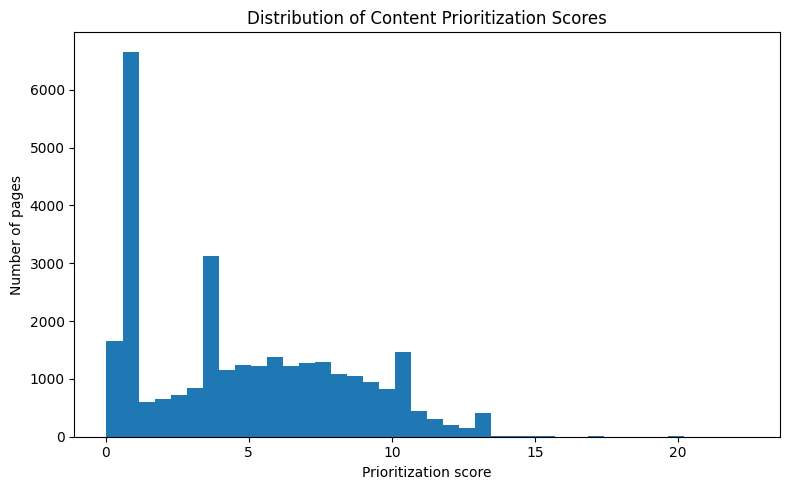

FRESHNESS-TIER SUMMARY


,freshness_tier,pages,median_score,median_days_since_update,median_trend_pct
0,0-30,20480,2.830000,20.0,-33.3
1,181+,174,10.033333,211.0,-44.5
2,31-90,175,4.936667,41.0,-38.5
3,91-180,9171,6.716667,104.0,-34.4



Figure saved: /content/flyrank-ml-internship-starter/work/figures/capstone_score_distribution.png
Summary saved: /content/flyrank-ml-internship-starter/work/outputs/capstone_freshness_summary.csv


In [21]:
# Capstone — Artifacts for the research paper

import os
import matplotlib.pyplot as plt

FIG_DIR = f"{REPO}/work/figures"
OUTPUT_DIR = f"{REPO}/work/outputs"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Score distribution
plt.figure(figsize=(8, 5))
plt.hist(model_df["score"], bins=40)
plt.xlabel("Prioritization score")
plt.ylabel("Number of pages")
plt.title("Distribution of Content Prioritization Scores")
plt.tight_layout()

score_fig = f"{FIG_DIR}/capstone_score_distribution.png"
plt.savefig(score_fig, dpi=150, bbox_inches="tight")
plt.show()

# 2. Freshness-tier summary
freshness_summary = (
    model_df.groupby("freshness_tier")
    .agg(
        pages=("content_id", "count"),
        median_score=("score", "median"),
        median_days_since_update=("days_since_last_update", "median"),
        median_trend_pct=("trend_pct", "median")
    )
    .reset_index()
)

print("FRESHNESS-TIER SUMMARY")
display(freshness_summary)

summary_path = f"{OUTPUT_DIR}/capstone_freshness_summary.csv"
freshness_summary.to_csv(summary_path, index=False)

print(f"\nFigure saved: {score_fig}")
print(f"Summary saved: {summary_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.